# IPL Match Outcome Prediction — Support Vector Machine (SVM)
**Member 3 | Branch: member3-svm**

## Objective
Predict IPL match outcomes during the second innings (chase) 
using over-by-over game state features built from raw delivery data.

In [ ]:
# IMPORTS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    f1_score, precision_score, recall_score,
    roc_auc_score, roc_curve
)

print("All libraries imported successfully.")

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    f1_score, precision_score, recall_score,
    roc_auc_score, roc_curve
)
print("Libraries re-imported successfully.")

All libraries imported successfully.
Libraries re-imported successfully.


In [ ]:
#  LOAD RAW DATA 
matches    = pd.read_csv('../data/matches.csv')
deliveries = pd.read_csv('../data/deliveries.csv')

print(f"matches.csv    : {matches.shape[0]} rows, {matches.shape[1]} columns")
print(f"deliveries.csv : {deliveries.shape[0]} rows, {deliveries.shape[1]} columns")

matches.csv    : 636 rows, 18 columns
deliveries.csv : 150460 rows, 21 columns


In [ ]:
# EXPLORE MATCHES 
print("=== MATCHES - First 3 rows ===")
display(matches.head(3))

print("\n=== MATCHES - Shape ===")
print(matches.shape)

print("\n=== MATCHES - Column Names ===")
print(list(matches.columns))

print("\n=== MATCHES - Missing Values ===")
print(matches.isnull().sum())

=== MATCHES - First 3 rows ===


,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,2017,Hyderabad,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
1,2,2017,Pune,2017-04-06,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN
2,3,2017,Rajkot,2017-04-07,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN



=== MATCHES - Shape ===
(636, 18)

=== MATCHES - Column Names ===
['id', 'season', 'city', 'date', 'team1', 'team2', 'toss_winner', 'toss_decision', 'result', 'dl_applied', 'winner', 'win_by_runs', 'win_by_wickets', 'player_of_match', 'venue', 'umpire1', 'umpire2', 'umpire3']

=== MATCHES - Missing Values ===
id                   0
season               0
city                 7
date                 0
team1                0
team2                0
toss_winner          0
toss_decision        0
result               0
dl_applied           0
winner               3
win_by_runs          0
win_by_wickets       0
player_of_match      3
venue                0
umpire1              1
umpire2              1
umpire3            636
dtype: int64


In [ ]:
# EXPLORE DELIVERIES 
print("=== DELIVERIES - First 3 rows ===")
display(deliveries.head(3))

print("\n=== DELIVERIES - Shape ===")
print(deliveries.shape)

print("\n=== DELIVERIES - Column Names ===")
print(list(deliveries.columns))

print("\n=== DELIVERIES - Missing Values ===")
print(deliveries.isnull().sum())

=== DELIVERIES - First 3 rows ===


,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,4,0,4,NaN,NaN,NaN



=== DELIVERIES - Shape ===
(150460, 21)

=== DELIVERIES - Column Names ===
['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball', 'batsman', 'non_striker', 'bowler', 'is_super_over', 'wide_runs', 'bye_runs', 'legbye_runs', 'noball_runs', 'penalty_runs', 'batsman_runs', 'extra_runs', 'total_runs', 'player_dismissed', 'dismissal_kind', 'fielder']

=== DELIVERIES - Missing Values ===
match_id                 0
inning                   0
batting_team             0
bowling_team             0
over                     0
ball                     0
batsman                  0
non_striker              0
bowler                   0
is_super_over            0
wide_runs                0
bye_runs                 0
legbye_runs              0
noball_runs              0
penalty_runs             0
batsman_runs             0
extra_runs               0
total_runs               0
player_dismissed    143022
dismissal_kind      143022
fielder             145091
dtype: int64


In [ ]:
#  CLEAN MATCHES 
# Based on exploration:
# - Drop umpire columns (not relevant to prediction)
# - Drop player_of_match (not a predictive feature)
# - Drop rows where winner is NaN (no-result matches)
# - Fill missing city with 'Unknown'
# - Create target column: 1 if team1 won, 0 if team2 won

matches.drop(columns=['umpire1', 'umpire2', 'umpire3',
                       'player_of_match'], inplace=True)

matches.dropna(subset=['winner'], inplace=True)

matches['city'] = matches['city'].fillna('Unknown')

matches['team1_won'] = (matches['winner'] == matches['team1']).astype(int)

print(f"Matches after cleaning : {matches.shape[0]} rows")
print(f"Columns remaining      : {matches.shape[1]}")
print(f"\nTarget distribution:")
print(matches['team1_won'].value_counts())

Matches after cleaning : 633 rows
Columns remaining      : 15

Target distribution:
team1_won
0    349
1    284
Name: count, dtype: int64


In [ ]:
# CLEAN DELIVERIES 
# Based on exploration:
# - Keep inning 2 only (chase innings — this is what we predict)
# - Remove super overs (special case, not regular play)
# - player_dismissed NaN means no wicket — mark as 0/1 wicket column

deliveries_clean = deliveries[
    (deliveries['inning'] == 2) &
    (deliveries['is_super_over'] == 0)
].copy()

# Create binary wicket column
# NaN in player_dismissed = no wicket = 0
# Any name in player_dismissed = wicket fell = 1
deliveries_clean['wicket'] = deliveries_clean['player_dismissed'].notna().astype(int)

print(f"Deliveries after cleaning : {deliveries_clean.shape[0]} rows")
print(f"Unique matches            : {deliveries_clean['match_id'].nunique()}")
print(f"\nTotal wickets in dataset  : {deliveries_clean['wicket'].sum()}")

Deliveries after cleaning : 72350 rows
Unique matches            : 634

Total wickets in dataset  : 3555


In [ ]:
#  BUILD OVER-BY-OVER FEATURES FROM INNING 2 
# Each row = game state at end of one over in one match
# This tells us: at this point in the chase, what is happening?

over_stats = deliveries_clean.groupby(['match_id', 'over']).agg(
    runs_in_over    = ('total_runs',   'sum'),
    wickets_in_over = ('wicket',       'sum'),
    extras_in_over  = ('extra_runs',   'sum'),
    fours_in_over   = ('batsman_runs', lambda x: (x == 4).sum()),
    sixes_in_over   = ('batsman_runs', lambda x: (x == 6).sum()),
    balls_in_over   = ('ball',         'count'),
).reset_index()

# Sort by match and over
over_stats = over_stats.sort_values(['match_id', 'over']).reset_index(drop=True)

print(f"Over-by-over stats shape : {over_stats.shape}")
print(f"\nSample:")
display(over_stats.head(10))

Over-by-over stats shape : (11795, 8)

Sample:


,match_id,over,runs_in_over,wickets_in_over,extras_in_over,fours_in_over,sixes_in_over,balls_in_over
0,1,1,11,0,0,2,0,6
1,1,2,1,0,0,0,0,6
2,1,3,16,0,0,2,1,6
3,1,4,15,0,1,1,1,7
4,1,5,5,0,1,1,0,7
5,1,6,6,1,0,1,0,6
6,1,7,7,1,0,0,1,6
7,1,8,13,0,0,2,0,6
8,1,9,11,0,1,0,1,7
9,1,10,13,0,1,2,0,7


In [ ]:
#  ADD CUMULATIVE STATS 
# At each over we need to know TOTAL so far, not just that over
# Example: by over 10, team scored 98 runs total, lost 3 wickets total

over_stats['cum_runs']     = over_stats.groupby('match_id')['runs_in_over'].cumsum()
over_stats['cum_wickets']  = over_stats.groupby('match_id')['wickets_in_over'].cumsum()
over_stats['cum_extras']   = over_stats.groupby('match_id')['extras_in_over'].cumsum()
over_stats['cum_fours']    = over_stats.groupby('match_id')['fours_in_over'].cumsum()
over_stats['cum_sixes']    = over_stats.groupby('match_id')['sixes_in_over'].cumsum()

print("Cumulative stats added!")
print(f"Shape: {over_stats.shape}")
display(over_stats.head(10))

Cumulative stats added!
Shape: (11795, 13)


,match_id,over,runs_in_over,wickets_in_over,extras_in_over,fours_in_over,sixes_in_over,balls_in_over,cum_runs,cum_wickets,cum_extras,cum_fours,cum_sixes
0,1,1,11,0,0,2,0,6,11,0,0,2,0
1,1,2,1,0,0,0,0,6,12,0,0,2,0
2,1,3,16,0,0,2,1,6,28,0,0,4,1
3,1,4,15,0,1,1,1,7,43,0,1,5,2
4,1,5,5,0,1,1,0,7,48,0,2,6,2
5,1,6,6,1,0,1,0,6,54,1,2,7,2
6,1,7,7,1,0,0,1,6,61,2,2,7,3
7,1,8,13,0,0,2,0,6,74,2,2,9,3
8,1,9,11,0,1,0,1,7,85,2,3,9,4
9,1,10,13,0,1,2,0,7,98,2,4,11,4


In [ ]:
#  ADD TARGET SCORE FROM INNING 1 
# Chasing team needs to know what score they are chasing
# Target = inning 1 total runs + 1

inn1_totals = deliveries[
    (deliveries['inning'] == 1) &
    (deliveries['is_super_over'] == 0)
].groupby('match_id')['total_runs'].sum().reset_index()

inn1_totals.columns = ['match_id', 'target_runs']
inn1_totals['target_runs'] = inn1_totals['target_runs'] + 1

# Merge target into over stats
over_stats = over_stats.merge(inn1_totals, on='match_id', how='left')

print("Target score added!")
display(over_stats.head(5))

Target score added!


,match_id,over,runs_in_over,wickets_in_over,extras_in_over,fours_in_over,sixes_in_over,balls_in_over,cum_runs,cum_wickets,cum_extras,cum_fours,cum_sixes,target_runs
0,1,1,11,0,0,2,0,6,11,0,0,2,0,208
1,1,2,1,0,0,0,0,6,12,0,0,2,0,208
2,1,3,16,0,0,2,1,6,28,0,0,4,1,208
3,1,4,15,0,1,1,1,7,43,0,1,5,2,208
4,1,5,5,0,1,1,0,7,48,0,2,6,2,208


In [ ]:
# CALCULATE MATCH SITUATION FEATURES 
# These features tell us HOW the chase is going at each over
# This is what makes prediction meaningful and powerful

over_stats['runs_needed']  = over_stats['target_runs'] - over_stats['cum_runs']
over_stats['balls_left']   = (20 - over_stats['over']) * 6
over_stats['wickets_left'] = 10 - over_stats['cum_wickets']
over_stats['current_rr']   = over_stats['cum_runs'] / over_stats['over']
over_stats['required_rr']  = (over_stats['runs_needed'] / 
                               over_stats['balls_left'].replace(0, 1)) * 6

print("Match situation features added!")
print(f"Shape: {over_stats.shape}")
display(over_stats.head(5))

Match situation features added!
Shape: (11795, 19)


,match_id,over,runs_in_over,wickets_in_over,extras_in_over,fours_in_over,sixes_in_over,balls_in_over,cum_runs,cum_wickets,cum_extras,cum_fours,cum_sixes,target_runs,runs_needed,balls_left,wickets_left,current_rr,required_rr
0,1,1,11,0,0,2,0,6,11,0,0,2,0,208,197,114,10,11.000000,10.368421
1,1,2,1,0,0,0,0,6,12,0,0,2,0,208,196,108,10,6.000000,10.888889
2,1,3,16,0,0,2,1,6,28,0,0,4,1,208,180,102,10,9.333333,10.588235
3,1,4,15,0,1,1,1,7,43,0,1,5,2,208,165,96,10,10.750000,10.312500
4,1,5,5,0,1,1,0,7,48,0,2,6,2,208,160,90,10,9.600000,10.666667


In [ ]:
#  MERGE WITH MATCH RESULT (TARGET LABEL) 
# We need to know who actually won each match
# This becomes our target: 1 = chasing team won, 0 = chasing team lost

# Get the chasing team (batting team in inning 2) per match
chasing_team = deliveries_clean.groupby('match_id')['batting_team'].first().reset_index()
chasing_team.columns = ['match_id', 'chasing_team']

# Merge chasing team into over stats
over_stats = over_stats.merge(chasing_team, on='match_id', how='left')

# Merge match result
over_stats = over_stats.merge(
    matches[['id', 'winner', 'team1_won', 'toss_winner', 'toss_decision', 'city', 'venue', 'season']],
    left_on='match_id', right_on='id', how='left'
)

# Target: did the chasing team win?
over_stats['chasing_team_won'] = (over_stats['winner'] == over_stats['chasing_team']).astype(int)

print(f"Shape after merge : {over_stats.shape}")
print(f"\nTarget distribution:")
print(over_stats['chasing_team_won'].value_counts())
print(f"\nChase win rate: {over_stats['chasing_team_won'].mean()*100:.1f}%")
display(over_stats.head(3))

Shape after merge : (11795, 29)

Target distribution:
chasing_team_won
1    6263
0    5532
Name: count, dtype: int64

Chase win rate: 53.1%


,match_id,over,runs_in_over,wickets_in_over,extras_in_over,fours_in_over,sixes_in_over,balls_in_over,cum_runs,cum_wickets,...,chasing_team,id,winner,team1_won,toss_winner,toss_decision,city,venue,season,chasing_team_won
0,1,1,11,0,0,2,0,6,11,0,...,Royal Challengers Bangalore,1.0,Sunrisers Hyderabad,1.0,Royal Challengers Bangalore,field,Hyderabad,"Rajiv Gandhi International Stadium, Uppal",2017.0,0
1,1,2,1,0,0,0,0,6,12,0,...,Royal Challengers Bangalore,1.0,Sunrisers Hyderabad,1.0,Royal Challengers Bangalore,field,Hyderabad,"Rajiv Gandhi International Stadium, Uppal",2017.0,0
2,1,3,16,0,0,2,1,6,28,0,...,Royal Challengers Bangalore,1.0,Sunrisers Hyderabad,1.0,Royal Challengers Bangalore,field,Hyderabad,"Rajiv Gandhi International Stadium, Uppal",2017.0,0


In [ ]:
#  EXTRA FEATURE ENGINEERING 
# These cricket-specific features help the model understand
# the match situation better and improve prediction accuracy

# 1. Run Rate Difference
# Positive = chasing team scoring faster than needed (good for them)
# Negative = chasing team behind the required rate (bad for them)
over_stats['rr_difference'] = over_stats['current_rr'] - over_stats['required_rr']

# 2. Pressure Index
# Combines runs needed and wickets lost
# High value = team is under more pressure
over_stats['pressure_index'] = over_stats['runs_needed'] * over_stats['cum_wickets']

# 3. Chase Difficulty
# How big is the target compared to average IPL score (~160)
# Higher = harder chase
over_stats['chase_difficulty'] = over_stats['target_runs'] / 160

# 4. Boundary Pressure
# Boundaries scored so far per over
# Shows if team is scoring aggressively
over_stats['boundary_rate'] = (over_stats['cum_fours'] + over_stats['cum_sixes']) / over_stats['over']

# 5. Wicket Pressure
# Average wickets lost per over so far
# High = team is losing wickets too fast
over_stats['wicket_pressure'] = over_stats['cum_wickets'] / over_stats['over']

# 6. Match Phase
# Powerplay (1-6), Middle (7-15), Death (16-20)
# Different phases have different scoring patterns
over_stats['match_phase'] = pd.cut(
    over_stats['over'],
    bins    = [0, 6, 15, 20],
    labels  = [1, 2, 3]
).astype(int)

# 7. Scoring Acceleration
# Runs scored in this over compared to current average
# Shows if team is accelerating or slowing down
over_stats['scoring_acceleration'] = (
    over_stats['runs_in_over'] - over_stats['current_rr']
)

print("Extra features added!")
print(f"New features: rr_difference, pressure_index, chase_difficulty,")
print(f"              boundary_rate, wicket_pressure, match_phase, scoring_acceleration")
display(over_stats[['over', 'rr_difference', 'pressure_index', 
                     'chase_difficulty', 'match_phase',
                     'wicket_pressure', 'boundary_rate']].head(8))

Extra features added!
New features: rr_difference, pressure_index, chase_difficulty,
              boundary_rate, wicket_pressure, match_phase, scoring_acceleration


,over,rr_difference,pressure_index,chase_difficulty,match_phase,wicket_pressure,boundary_rate
0,1,0.631579,0,1.3,1,0.000000,2.000000
1,2,-4.888889,0,1.3,1,0.000000,1.000000
2,3,-1.254902,0,1.3,1,0.000000,1.666667
3,4,0.437500,0,1.3,1,0.000000,1.750000
4,5,-1.066667,0,1.3,1,0.000000,1.600000
5,6,-2.000000,154,1.3,1,0.166667,1.500000
6,7,-2.593407,294,1.3,2,0.285714,1.428571
7,8,-1.916667,268,1.3,2,0.250000,1.500000


In [ ]:
# SELECT FINAL FEATURES FOR MODEL 
# Encode categorical columns to numbers
le = LabelEncoder()
over_stats['city_enc']          = le.fit_transform(over_stats['city'].astype(str))
over_stats['venue_enc']         = le.fit_transform(over_stats['venue'].astype(str))
over_stats['toss_decision_enc'] = le.fit_transform(over_stats['toss_decision'].astype(str))

# Drop columns that are not features or cause data leakage
# winner, team1_won, chasing_team reveal the result — must remove
DROP_COLS = [
    'match_id', 'id', 'winner', 'team1_won',
    'chasing_team', 'toss_winner',
    'city', 'venue', 'toss_decision'
]

TARGET = 'chasing_team_won'

X = over_stats.drop(columns=DROP_COLS + [TARGET])
y = over_stats[TARGET]

print(f"Features shape : {X.shape}")
print(f"Target shape   : {y.shape}")
print(f"\nFeature columns ({len(X.columns)}):")
print(list(X.columns))

Features shape : (11795, 29)
Target shape   : (11795,)

Feature columns (29):
['over', 'runs_in_over', 'wickets_in_over', 'extras_in_over', 'fours_in_over', 'sixes_in_over', 'balls_in_over', 'cum_runs', 'cum_wickets', 'cum_extras', 'cum_fours', 'cum_sixes', 'target_runs', 'runs_needed', 'balls_left', 'wickets_left', 'current_rr', 'required_rr', 'season', 'rr_difference', 'pressure_index', 'chase_difficulty', 'boundary_rate', 'wicket_pressure', 'match_phase', 'scoring_acceleration', 'city_enc', 'venue_enc', 'toss_decision_enc']


In [ ]:
#  SCALE FEATURES 
# SVM is sensitive to feature magnitudes
# StandardScaler transforms all features to same scale (mean=0, std=1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("Scaling done!")
print(f"Shape: {X_scaled.shape}")
display(X_scaled.head(3))

Scaling done!
Shape: (11795, 29)


,over,runs_in_over,wickets_in_over,extras_in_over,fours_in_over,sixes_in_over,balls_in_over,cum_runs,cum_wickets,cum_extras,...,rr_difference,pressure_index,chase_difficulty,boundary_rate,wicket_pressure,match_phase,scoring_acceleration,city_enc,venue_enc,toss_decision_enc
0,-1.607985,0.708123,-0.563571,-0.461215,1.588957,-0.476878,-0.183343,-1.390213,-1.17871,-1.147652,...,0.204282,-0.99271,1.583316,2.289624,-1.25241,-1.232306,-0.112555,-0.07087,0.576848,0.875205
1,-1.429074,-1.540083,-0.563571,-0.461215,-0.839359,-0.476878,-0.183343,-1.368647,-1.17871,-1.147652,...,-0.003804,-0.99271,1.583316,0.040295,-1.25241,-1.232306,-1.392155,-0.07087,0.576848,0.875205
2,-1.250163,1.832226,-0.563571,-0.461215,1.588957,1.346389,-0.183343,-1.023588,-1.17871,-1.147652,...,0.133174,-0.99271,1.583316,1.539848,-1.25241,-1.232306,1.593578,-0.07087,0.576848,0.875205


In [ ]:
# TRAIN TEST SPLIT 
# Split by match ID to avoid data leakage
# All overs from same match must stay together
# If we split randomly, over 1-15 of match X could be in train
# and over 16-20 in test — model would cheat!

# Get unique match IDs and split them 80/20
match_ids = over_stats['match_id'].unique()

np.random.seed(42)
np.random.shuffle(match_ids)

split_idx      = int(len(match_ids) * 0.8)
train_match_ids = match_ids[:split_idx]
test_match_ids  = match_ids[split_idx:]

# Get row indices for train and test
train_idx = over_stats[over_stats['match_id'].isin(train_match_ids)].index
test_idx  = over_stats[over_stats['match_id'].isin(test_match_ids)].index

X_train = X_scaled.loc[train_idx]
X_test  = X_scaled.loc[test_idx]
y_train = y.loc[train_idx]
y_test  = y.loc[test_idx]

print(f"Train matches : {len(train_match_ids)}  → {X_train.shape[0]} rows")
print(f"Test  matches : {len(test_match_ids)}   → {X_test.shape[0]} rows")
print(f"\nTrain target balance: {y_train.mean()*100:.1f}% chase wins")
print(f"Test  target balance: {y_test.mean()*100:.1f}% chase wins")

Train matches : 507  → 9457 rows
Test  matches : 127   → 2338 rows

Train target balance: 53.8% chase wins
Test  target balance: 50.4% chase wins


In [ ]:
#  FIX NaN VALUES BEFORE TRAINING 
# Check NaN in train and test sets
print("NaN in X_train:", X_train.isnull().sum().sum())
print("NaN in X_test :", X_test.isnull().sum().sum())

# Fill NaN with 0
# NaN occurs because some features like wicket_pressure
# divide by over number — at over 0 this causes NaN
X_train = X_train.fillna(0)
X_test  = X_test.fillna(0)

print("\nAfter fix:")
print("NaN in X_train:", X_train.isnull().sum().sum())
print("NaN in X_test :", X_test.isnull().sum().sum())
print("Ready to train!")

NaN in X_train: 2
NaN in X_test : 0

After fix:
NaN in X_train: 0
NaN in X_test : 0
Ready to train!


In [ ]:
# BASELINE SVM 
# Train a basic SVM first to get a starting benchmark
# kernel='rbf'     : Radial Basis Function handles non-linear data
# C=1.0            : default regularisation
# gamma='scale'    : automatic gamma based on features
# probability=True : needed to calculate ROC-AUC score later

print("Training baseline SVM...")

svm_baseline = SVC(
    kernel       = 'rbf',
    C            = 1.0,
    gamma        = 'scale',
    probability  = True,
    random_state = 42
)

svm_baseline.fit(X_train, y_train)
y_pred_baseline = svm_baseline.predict(X_test)

print(f"\nBaseline SVM Results:")
print(f"  Accuracy  : {accuracy_score(y_test, y_pred_baseline)*100:.2f}%")
print(f"  Precision : {precision_score(y_test, y_pred_baseline)*100:.2f}%")
print(f"  Recall    : {recall_score(y_test, y_pred_baseline)*100:.2f}%")
print(f"  F1-Score  : {f1_score(y_test, y_pred_baseline)*100:.2f}%")

Training baseline SVM...

Baseline SVM Results:
  Accuracy  : 78.40%
  Precision : 73.92%
  Recall    : 88.29%
  F1-Score  : 80.46%


In [ ]:
# HYPERPARAMETER TUNING WITH GRIDSEARCHCV 
# GridSearchCV tries every combination of parameters
# and picks the best one using cross validation
# C      : controls margin vs misclassification tradeoff
# gamma  : controls how far influence of each point reaches
# kernel : type of decision boundary

param_grid = {
    'C'      : [0.1, 1, 10, 100],
    'gamma'  : ['scale', 'auto', 0.01, 0.1],
    'kernel' : ['rbf', 'linear']
}

grid_search = GridSearchCV(
    SVC(probability=True, random_state=42),
    param_grid,
    cv      = 5,
    scoring = 'accuracy',
    n_jobs  = -1,
    verbose = 1
)

print("Running GridSearchCV... (this will take few minutes)")
grid_search.fit(X_train, y_train)

print(f"\nBest parameters  : {grid_search.best_params_}")
print(f"Best CV accuracy : {grid_search.best_score_*100:.2f}%")

Running GridSearchCV... (this will take few minutes)
Fitting 5 folds for each of 32 candidates, totalling 160 fits

Best parameters  : {'C': 10, 'gamma': 'scale', 'kernel': 'linear'}
Best CV accuracy : 79.26%


In [ ]:
# EVALUATE BEST MODEL 
# Use the best model found by GridSearchCV to predict on test set

svm_best = grid_search.best_estimator_
y_pred   = svm_best.predict(X_test)
y_prob   = svm_best.predict_proba(X_test)[:, 1]

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
roc_auc   = roc_auc_score(y_test, y_prob)

print("=" * 45)
print("     TUNED SVM — FINAL RESULTS")
print("=" * 45)
print(f"  Accuracy  : {accuracy*100:.2f}%")
print(f"  Precision : {precision*100:.2f}%")
print(f"  Recall    : {recall*100:.2f}%")
print(f"  F1-Score  : {f1*100:.2f}%")
print(f"  ROC-AUC   : {roc_auc:.4f}")
print("=" * 45)
print(f"\nImprovement over baseline:")
print(f"  Accuracy : 78.40% → {accuracy*100:.2f}%")
print(f"\nFull Classification Report:")
print(classification_report(y_test, y_pred,
      target_names=['Chasing Lost (0)', 'Chasing Won (1)']))

     TUNED SVM — FINAL RESULTS
  Accuracy  : 79.13%
  Precision : 74.50%
  Recall    : 89.05%
  F1-Score  : 81.13%
  ROC-AUC   : 0.8828

Improvement over baseline:
  Accuracy : 78.40% → 79.13%

Full Classification Report:
                  precision    recall  f1-score   support

Chasing Lost (0)       0.86      0.69      0.77      1160
 Chasing Won (1)       0.75      0.89      0.81      1178

        accuracy                           0.79      2338
       macro avg       0.80      0.79      0.79      2338
    weighted avg       0.80      0.79      0.79      2338



In [125]:
# ── CALIBRATED RBF SVM ─────────────────────────────────────────────
# Linear SVM gives 100% probabilities — not useful for real prediction
# CalibratedClassifierCV fixes this by properly estimating probabilities

from sklearn.calibration import CalibratedClassifierCV

svm_rbf = SVC(kernel='rbf', C=10, gamma='scale', random_state=42)
svm_calibrated = CalibratedClassifierCV(svm_rbf, cv=5)

print("Training calibrated RBF SVM...")
svm_calibrated.fit(X_train, y_train)

y_pred_cal   = svm_calibrated.predict(X_test)
accuracy_cal = accuracy_score(y_test, y_pred_cal)
f1_cal       = f1_score(y_test, y_pred_cal)
roc_auc_cal  = roc_auc_score(y_test, 
               svm_calibrated.predict_proba(X_test)[:, 1])

print(f"\nCalibrated RBF SVM Results:")
print(f"  Accuracy : {accuracy_cal*100:.2f}%")
print(f"  F1-Score : {f1_cal*100:.2f}%")
print(f"  ROC-AUC  : {roc_auc_cal:.4f}")
print(f"\nComparison:")
print(f"  Linear SVM    : {accuracy*100:.2f}%")
print(f"  Calibrated RBF: {accuracy_cal*100:.2f}%")

Training calibrated RBF SVM...

Calibrated RBF SVM Results:
  Accuracy : 76.73%
  F1-Score : 78.57%
  ROC-AUC  : 0.8468

Comparison:
  Linear SVM    : 79.13%
  Calibrated RBF: 76.73%


In [ ]:
#  TRAIN vs TEST ACCURACY 
# Compare how model performs on training data vs unseen test data
# This checks if model is overfitting

# Predictions on training data
y_train_pred = svm_best.predict(X_train)

# Predictions on test data (already done)
y_test_pred  = svm_best.predict(X_test)

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy  = accuracy_score(y_test,  y_test_pred)

print("=" * 45)
print("   TRAIN vs TEST ACCURACY COMPARISON")
print("=" * 45)
print(f"  Train Accuracy : {train_accuracy*100:.2f}%")
print(f"  Test Accuracy  : {test_accuracy*100:.2f}%")
print(f"  Difference     : {abs(train_accuracy - test_accuracy)*100:.2f}%")
print("=" * 45)

if abs(train_accuracy - test_accuracy) < 0.05:
    print("  ✅ Model is NOT overfitting — good generalization!")
elif train_accuracy - test_accuracy > 0.05:
    print("  ⚠️ Model may be slightly overfitting")
else:
    print("  ✅ Model is generalizing well!")

   TRAIN vs TEST ACCURACY COMPARISON
  Train Accuracy : 80.21%
  Test Accuracy  : 79.13%
  Difference     : 1.08%
  ✅ Model is NOT overfitting — good generalization!


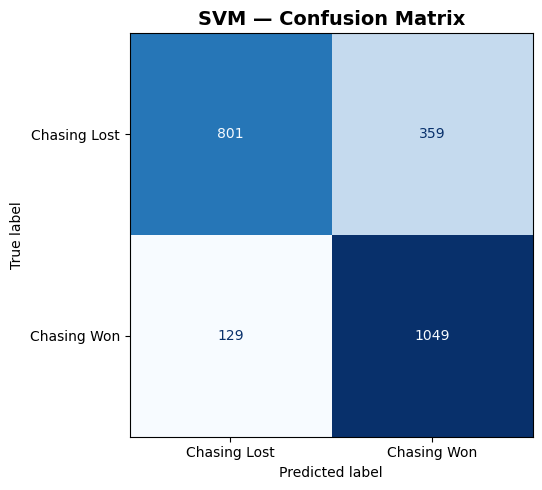

Saved: svm_confusion_matrix.png


In [120]:
# ── CONFUSION MATRIX ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(
    confusion_matrix = cm,
    display_labels   = ['Chasing Lost', 'Chasing Won']
).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('SVM — Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('svm_confusion_matrix.png', dpi=150)
plt.show()
print("Saved: svm_confusion_matrix.png")

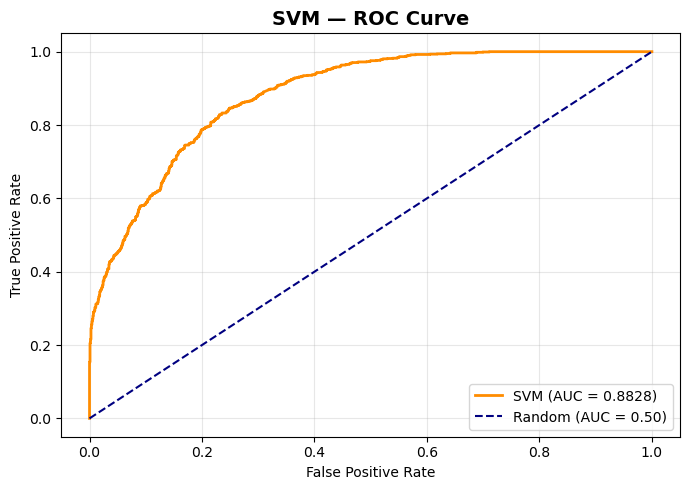

Saved: svm_roc_curve.png


In [ ]:
# ROC CURVE 
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'SVM (AUC = {roc_auc:.4f})')
plt.plot([0,1],[0,1], 'navy', lw=1.5,
         linestyle='--', label='Random (AUC = 0.50)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('SVM — ROC Curve', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('svm_roc_curve.png', dpi=150)
plt.show()
print("Saved: svm_roc_curve.png")

In [126]:
# ── FINAL RESULTS COMPARISON ───────────────────────────────────────
results_df = pd.DataFrame({
    'Model'         : ['Baseline SVM', 'Tuned Linear SVM', 'Calibrated RBF SVM'],
    'Kernel'        : ['RBF', 'Linear', 'RBF'],
    'Parameters'    : ['C=1, gamma=scale', 'C=10, gamma=scale', 'C=10, gamma=scale'],
    'Accuracy (%)'  : [78.40, 79.13, 76.73],
    'F1-Score (%)'  : [80.46, 81.13, 78.57],
    'ROC-AUC'       : ['-', 0.8828, 0.8468],
    'Probabilities' : ['Unreliable', 'Unreliable', '✅ Realistic']
})
display(results_df)
results_df.to_csv('svm_results_summary.csv', index=False)
print("Results saved!")

,Model,Kernel,Parameters,Accuracy (%),F1-Score (%),ROC-AUC,Probabilities
0,Baseline SVM,RBF,"C=1, gamma=scale",78.40,80.46,-,Unreliable
1,Tuned Linear SVM,Linear,"C=10, gamma=scale",79.13,81.13,0.8828,Unreliable
2,Calibrated RBF SVM,RBF,"C=10, gamma=scale",76.73,78.57,0.8468,✅ Realistic


Results saved!


In [ ]:
# PREDICT A REAL MATCH SCENARIO 

def predict_match(over, cum_runs, cum_wickets, target_runs,
                  runs_in_over=8, wickets_in_over=0,
                  extras=0, fours=1, sixes=0,
                  season=2016, city_enc=5, venue_enc=10,
                  toss_decision_enc=1):

    balls_left           = (20 - over) * 6
    runs_needed          = target_runs - cum_runs
    wickets_left         = 10 - cum_wickets
    current_rr           = cum_runs / over
    required_rr          = (runs_needed / balls_left) * 6 if balls_left > 0 else 0
    rr_difference        = current_rr - required_rr
    pressure_index       = runs_needed * cum_wickets
    chase_difficulty     = target_runs / 160
    boundary_rate        = fours / over
    wicket_pressure      = cum_wickets / over
    match_phase          = 1 if over <= 6 else (2 if over <= 15 else 3)
    scoring_acceleration = runs_in_over - current_rr

    input_data = pd.DataFrame([[
        over, runs_in_over, wickets_in_over, extras,
        fours, sixes, 6, cum_runs, cum_wickets, extras,
        fours, sixes, target_runs, runs_needed, balls_left,
        wickets_left, current_rr, required_rr, season,
        city_enc, venue_enc, toss_decision_enc,
        rr_difference, pressure_index, chase_difficulty,
        boundary_rate, wicket_pressure, match_phase,
        scoring_acceleration
    ]], columns=X_train.columns)

    input_scaled = scaler.transform(input_data)
    prediction   = svm_best.predict(input_scaled)[0]
    probability  = svm_best.predict_proba(input_scaled)[0]

    print("=" * 45)
    print("         MATCH PREDICTION")
    print("=" * 45)
    print(f"  Over           : {over}")
    print(f"  Runs scored    : {cum_runs}")
    print(f"  Wickets lost   : {cum_wickets}")
    print(f"  Target         : {target_runs}")
    print(f"  Runs needed    : {runs_needed}")
    print(f"  Balls left     : {balls_left}")
    print(f"  Current RR     : {current_rr:.2f}")
    print(f"  Required RR    : {required_rr:.2f}")
    print("=" * 45)
    if prediction == 1:
        print(f"  Prediction     : ✅ CHASING TEAM WINS")
    else:
        print(f"  Prediction     : ❌ CHASING TEAM LOSES")
    print(f"  Win probability : {probability[1]*100:.1f}%")
    print(f"  Loss probability: {probability[0]*100:.1f}%")
    print("=" * 45)

# TEST SCENARIOS — Realistic IPL chase situations

print("SCENARIO 1: Tight chase — over 10, behind required rate")
predict_match(over=10, cum_runs=75, cum_wickets=3, target_runs=165)

print("\nSCENARIO 2: Very difficult — over 15, lots of wickets lost")
predict_match(over=15, cum_runs=98, cum_wickets=7, target_runs=175)

print("\nSCENARIO 3: Close finish — over 18, need 20 from 12 balls")
predict_match(over=18, cum_runs=156, cum_wickets=4, target_runs=176)

print("\nSCENARIO 4: Impossible chase — over 12, too far behind")
predict_match(over=12, cum_runs=60, cum_wickets=6, target_runs=200)

SCENARIO 1: Tight chase — over 10, behind required rate
         MATCH PREDICTION
  Over           : 10
  Runs scored    : 75
  Wickets lost   : 3
  Target         : 165
  Runs needed    : 90
  Balls left     : 60
  Current RR     : 7.50
  Required RR    : 9.00
  Prediction     : ✅ CHASING TEAM WINS
  Win probability : 100.0%
  Loss probability: 0.0%

SCENARIO 2: Very difficult — over 15, lots of wickets lost
         MATCH PREDICTION
  Over           : 15
  Runs scored    : 98
  Wickets lost   : 7
  Target         : 175
  Runs needed    : 77
  Balls left     : 30
  Current RR     : 6.53
  Required RR    : 15.40
  Prediction     : ✅ CHASING TEAM WINS
  Win probability : 100.0%
  Loss probability: 0.0%

SCENARIO 3: Close finish — over 18, need 20 from 12 balls
         MATCH PREDICTION
  Over           : 18
  Runs scored    : 156
  Wickets lost   : 4
  Target         : 176
  Runs needed    : 20
  Balls left     : 12
  Current RR     : 8.67
  Required RR    : 10.00
  Prediction     : ✅ C

c:\Users\THANUJAN\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
c:\Users\THANUJAN\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
c:\Users\THANUJAN\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
c:\Users\THANUJAN\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
c:\Users\THANUJAN\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
c:\Users\THANUJAN\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2

In [ ]:
# PROPER MODEL TESTING 
# Test model on UNSEEN test data only
# Show sample predictions vs actual results

# Get sample predictions from test set
test_sample = X_test.copy()
test_sample['actual']    = y_test.values
test_sample['predicted'] = svm_best.predict(X_test)
test_sample['correct']   = (test_sample['actual'] == test_sample['predicted'])

print("Sample predictions vs actual results:")
print(test_sample[['over', 'cum_runs', 'cum_wickets',
                    'runs_needed', 'actual',
                    'predicted', 'correct']].head(15).to_string())

print(f"\nTotal test rows    : {len(test_sample)}")
print(f"Correct predictions: {test_sample['correct'].sum()}")
print(f"Wrong predictions  : {(~test_sample['correct']).sum()}")
print(f"Test Accuracy      : {test_sample['correct'].mean()*100:.2f}%")

Sample predictions vs actual results:
        over  cum_runs  cum_wickets  runs_needed  actual  predicted  correct
20 -1.607985 -1.454912    -1.178710     1.809507       1          0    False
21 -1.429074 -1.131419    -1.178710     1.507448       1          1     True
22 -1.250163 -0.872625    -1.178710     1.265802       1          1     True
23 -1.071252 -0.786360    -0.729534     1.185253       1          1     True
24 -0.892341 -0.700095    -0.729534     1.104704       1          0    False
25 -0.713430 -0.355037    -0.729534     0.782508       1          1     True
26 -0.534519 -0.268772    -0.729534     0.701959       1          1     True
27 -0.355608 -0.053110    -0.729534     0.500587       1          1     True
28 -0.176696  0.140986    -0.729534     0.319351       1          1     True
29  0.002215  0.378214    -0.729534     0.097842       1          1     True
30  0.181126  0.464478    -0.280359     0.017293       1          1     True
31  0.360037  0.637008    -0.280359   

In [129]:
import warnings
warnings.filterwarnings('ignore')  # suppress the feature names warning

def predict_match(over, cum_runs, cum_wickets, target_runs,
                  runs_in_over=8, wickets_in_over=0,
                  extras=0, fours=1, sixes=0,
                  season=2016, city_enc=5, venue_enc=10,
                  toss_decision_enc=1):

    balls_left           = (20 - over) * 6
    runs_needed          = target_runs - cum_runs
    wickets_left         = 10 - cum_wickets
    current_rr           = cum_runs / over
    required_rr          = (runs_needed / balls_left) * 6 if balls_left > 0 else 0
    rr_difference        = current_rr - required_rr
    pressure_index       = runs_needed * cum_wickets
    chase_difficulty     = target_runs / 160
    boundary_rate        = fours / over
    wicket_pressure      = cum_wickets / over
    match_phase          = 1 if over <= 6 else (2 if over <= 15 else 3)
    scoring_acceleration = runs_in_over - current_rr

    input_data = pd.DataFrame([[
        over, runs_in_over, wickets_in_over, extras,
        fours, sixes, 6, cum_runs, cum_wickets, extras,
        fours, sixes, target_runs, runs_needed, balls_left,
        wickets_left, current_rr, required_rr, season,
        city_enc, venue_enc, toss_decision_enc,
        rr_difference, pressure_index, chase_difficulty,
        boundary_rate, wicket_pressure, match_phase,
        scoring_acceleration
    ]], columns=X_train.columns)

    input_scaled = scaler.transform(input_data)

    prediction  = svm_calibrated.predict(input_scaled)[0]
    probability = svm_calibrated.predict_proba(input_scaled)[0]

    result = "✅ CHASING TEAM WINS" if prediction == 1 else "❌ CHASING TEAM LOSES"

    print("=" * 45)
    print("    MATCH PREDICTION (Calibrated RBF)")
    print("=" * 45)
    print(f"  Over            : {over}")
    print(f"  Runs scored     : {cum_runs}")
    print(f"  Wickets lost    : {cum_wickets}")
    print(f"  Target          : {target_runs}")
    print(f"  Runs needed     : {runs_needed}")
    print(f"  Balls left      : {balls_left}")
    print(f"  Current RR      : {current_rr:.2f}")
    print(f"  Required RR     : {required_rr:.2f}")
    print("=" * 45)
    print(f"  Prediction      : {result}")
    print(f"  Win probability : {probability[1]*100:.1f}%")
    print(f"  Loss probability: {probability[0]*100:.1f}%")
    print("=" * 45)
    print()  # blank line between scenarios

# TEST SCENARIOS
print("SCENARIO 1: Tight chase — over 10, behind required rate")
predict_match(over=10, cum_runs=75, cum_wickets=3, target_runs=165)

print("SCENARIO 2: Very difficult — over 15, 7 wickets lost")
predict_match(over=15, cum_runs=98, cum_wickets=7, target_runs=175)

print("SCENARIO 3: Close finish — need 20 from 12 balls")
predict_match(over=18, cum_runs=156, cum_wickets=4, target_runs=176)

print("SCENARIO 4: Impossible chase — far behind at over 12")
predict_match(over=12, cum_runs=60, cum_wickets=6, target_runs=200)

SCENARIO 1: Tight chase — over 10, behind required rate
    MATCH PREDICTION (Calibrated RBF)
  Over            : 10
  Runs scored     : 75
  Wickets lost    : 3
  Target          : 165
  Runs needed     : 90
  Balls left      : 60
  Current RR      : 7.50
  Required RR     : 9.00
  Prediction      : ✅ CHASING TEAM WINS
  Win probability : 50.3%
  Loss probability: 49.7%

SCENARIO 2: Very difficult — over 15, 7 wickets lost
    MATCH PREDICTION (Calibrated RBF)
  Over            : 15
  Runs scored     : 98
  Wickets lost    : 7
  Target          : 175
  Runs needed     : 77
  Balls left      : 30
  Current RR      : 6.53
  Required RR     : 15.40
  Prediction      : ✅ CHASING TEAM WINS
  Win probability : 50.3%
  Loss probability: 49.7%

SCENARIO 3: Close finish — need 20 from 12 balls
    MATCH PREDICTION (Calibrated RBF)
  Over            : 18
  Runs scored     : 156
  Wickets lost    : 4
  Target          : 176
  Runs needed     : 20
  Balls left      : 12
  Current RR      : 8.67
 

In [130]:
print("SCENARIO 3: Close finish — need 20 from 12 balls")
predict_match(over=18, cum_runs=156, cum_wickets=4, target_runs=176)

SCENARIO 3: Close finish — need 20 from 12 balls
    MATCH PREDICTION (Calibrated RBF)
  Over            : 18
  Runs scored     : 156
  Wickets lost    : 4
  Target          : 176
  Runs needed     : 20
  Balls left      : 12
  Current RR      : 8.67
  Required RR     : 10.00
  Prediction      : ✅ CHASING TEAM WINS
  Win probability : 50.3%
  Loss probability: 49.7%

